## Memory

Memory in LangGraph allows AI agents to remember and adapt based on previous interactions, enhancing efficiency and user satisfaction. This capability is essential for handling complex tasks and maintaining context across multiple user interactions.

There are two main types of memory in LangGraph:

- **Short-term memory** 

- **Long-term memory** 

## Example Short Term Memory

**Short-term memory:** Stores data within a single thread or session. It helps agents remember ongoing conversations and interactions within the current session, updating as the graph progresses through steps.

**Short-term memory** is especially useful for managing ongoing dialogue, ensuring the agent doesn’t forget recent user input while working within the limited context window of models.

    However, maintaining conversation history can become challenging in long sessions due to context limitations of LLMs (Large Language Models). Therefore, techniques like forgetting stale information or filtering are used to ensure the model works efficiently with long conversations.

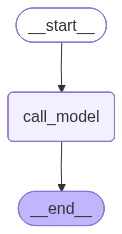

In [1]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage
# Define a simple model node

def call_model(state: MessagesState):
    last_user_message = state["messages"][-1].content
    response = AIMessage(content=f"You said: {last_user_message}")
    return {"messages": state["messages"] + [response]}
    
# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.set_entry_point("call_model")
builder.add_edge("call_model", END)
# Add short-term memory using in-memory checkpointer

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
# Invoke the graph with a thread ID
graph



In [2]:
graph.invoke(
    {"messages": [HumanMessage(content="Hi, I'm ABC")]},
    {"configurable": {"thread_id": "thread-1"}}
)

{'messages': [HumanMessage(content="Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='f4b6e09c-b4cf-49a3-bd21-ac41d38025fa'),
  AIMessage(content="You said: Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='a004898e-a6a9-4e2d-8e7b-31f930b0e265')]}

In [3]:
graph.invoke(
    {"messages": [HumanMessage(content="I want to learn ML")]},
    {"configurable": {"thread_id": "thread-1"}}
)

{'messages': [HumanMessage(content="Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='f4b6e09c-b4cf-49a3-bd21-ac41d38025fa'),
  AIMessage(content="You said: Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='a004898e-a6a9-4e2d-8e7b-31f930b0e265'),
  HumanMessage(content='I want to learn ML', additional_kwargs={}, response_metadata={}, id='d56e5fce-020a-4a56-b63e-84acdd6dccfd'),
  AIMessage(content='You said: I want to learn ML', additional_kwargs={}, response_metadata={}, id='3c67073f-1833-436a-9c69-188e8336bc7e')]}

In [5]:
graph.invoke(
    {"messages": [HumanMessage(content="I want to learn AI and ML")]},
    {"configurable": {"thread_id": "thread-1"}}
)

{'messages': [HumanMessage(content="Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='f4b6e09c-b4cf-49a3-bd21-ac41d38025fa'),
  AIMessage(content="You said: Hi, I'm ABC", additional_kwargs={}, response_metadata={}, id='a004898e-a6a9-4e2d-8e7b-31f930b0e265'),
  HumanMessage(content='I want to learn ML', additional_kwargs={}, response_metadata={}, id='d56e5fce-020a-4a56-b63e-84acdd6dccfd'),
  AIMessage(content='You said: I want to learn ML', additional_kwargs={}, response_metadata={}, id='3c67073f-1833-436a-9c69-188e8336bc7e'),
  HumanMessage(content='I want to learn AI and ML', additional_kwargs={}, response_metadata={}, id='9ff1d069-3309-431b-bf4f-ae3171be3a46'),
  AIMessage(content='You said: I want to learn AI and ML', additional_kwargs={}, response_metadata={}, id='d52a3124-4509-4334-b00f-3de027f863c9')]}

### Example 2 Short-term Memory With LLM Agent

#### Financial Advisor AI with Conversation Memory

Design and implement a Financial Advisor AI assistant that helps users make better financial decisions. The assistant should provide ethical, conservative, and practical financial advice based on the user's questions and financial context.

The system must be able to **remember previous conversations** for the same user so that advice can be personalized and consistent across multiple interactions.

In [5]:
import time
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.store.base import BaseStore
from langgraph.graph import START, MessagesState, StateGraph, END
from langchain_aws import ChatBedrockConverse
from langgraph.checkpoint.memory import InMemorySaver

#  Bedrock LLM Setup 
model = ChatBedrockConverse(
    model_id="anthropic.claude-3-sonnet-20240229-v1:0", 
    region_name="us-east-1",  
    temperature=0.4,
    max_tokens=100
)

# Define the Chatbot Interaction 
def chat(state: MessagesState) -> dict:
    """
    Handles the user message, processes it, and invokes the Bedrock LLM to generate a response.
    """
    
   
    # system prompt -
    system_prompt = (
        "You are a helpful, ethical, and conservative **Financial Advisor AI**. "
        "Use the user's message to provide professional, financial advice. "
        "Keep your answers focused on financial well-being."
        "You can refer previous conversations to answer user queries if required."
    )

    response = model.invoke(
        [
            {"role": "system", "content": system_prompt},
            *state["messages"],  # Include the user message in the context
        ]
    )

    return {"messages": [response]}

#  Build the Graph ---
builder = StateGraph(MessagesState)
builder.add_node("chat_node", chat)  # Add chat logic to the graph
builder.add_edge(START, "chat_node")  # Connect start to the chat node
builder.add_edge("chat_node", END)    # Connect chat node to the end

# Compile the Graph with InMemorySaver ---
graph = builder.compile(checkpointer=InMemorySaver())  # Use InMemorySaver for state checkpointing



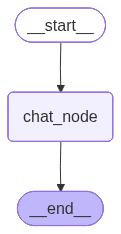

In [6]:
graph

In [7]:
from rich import print

while True:
    # Get user input and thread_id
    user_input = input("User: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Chatbot has ended.")
        break

    thread_id = input("Thread ID: ")

    # Create the message and config for graph.stream
    messages = [{"role": "user", "content": user_input}]  # Ensure the first message is from the user
    config = {"configurable": {"thread_id": thread_id}}  # Config for thread_id
    # Using graph.stream with the correct structure
    for step in graph.stream({"messages": messages}, config=config):
        # Print AI's response (assuming step contains the response)
        print(step)  # Get the AI's response content


User:  Hi , I am an Engineer
Thread ID:  1


{
    'chat_node': {
        'messages': [
            AIMessage(
                content="Hello there! As a Financial Advisor AI, I'm happy to provide you with professional 
guidance on managing your finances effectively as an engineer. Here are some general tips that could be 
helpful:\n\n1. Budgeting: Create a detailed budget that accounts for your income, fixed expenses (rent, utilities, 
loan payments), variable expenses (groceries, entertainment), and savings goals. Stick to this budget diligently to
ensure you're living within your means.\n\n2. Emergency Fun",
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': '071af407-8d16-44e2-8bd7-54edbb4e0faf',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 08 Dec 2025 08:47:43 GMT',
                            'content-type': 'application/json',
                            'content-length': '684',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': '071af407-8d16-44e2-8bd7-54edbb4e0faf'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'max_tokens',
                    'metrics': {'latencyMs': [1827]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--fc443ea8-51a2-411b-a1ec-0c6db1e857b4-0',
                usage_metadata={
                    'input_tokens': 51,
                    'output_tokens': 100,
                    'total_tokens': 151,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

User:  I want to learn ML and AI
Thread ID:  1


{
    'chat_node': {
        'messages': [
            AIMessage(
                content="As an engineer interested in learning machine learning (ML) and artificial intelligence 
(AI), here are some financial considerations:\n\n1. Upskilling Costs: Getting trained in ML and AI can be 
expensive, especially if you plan to take courses, get certifications, or pursue higher education like a master's 
degree. Factor in the costs of training programs, course fees, books, etc. into your budget.\n\n2. Career 
Prospects: ML and AI skills are in high demand across",
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': 'c8cb72ed-faed-4825-ac14-fc8a24466fb5',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 08 Dec 2025 08:47:53 GMT',
                            'content-type': 'application/json',
                            'content-length': '675',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': 'c8cb72ed-faed-4825-ac14-fc8a24466fb5'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'max_tokens',
                    'metrics': {'latencyMs': [2028]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--2d93e4d9-a85e-4d08-9b6a-43b7869bcb57-0',
                usage_metadata={
                    'input_tokens': 164,
                    'output_tokens': 100,
                    'total_tokens': 264,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

User:  What is my profession ?
Thread ID:  1


{
    'chat_node': {
        'messages': [
            AIMessage(
                content='From your initial message, you stated that you are an Engineer. As a Financial Advisor AI,
I do not actually have specific information about your profession beyond that statement. \n\nHowever, based on you 
being an Engineer interested in learning machine learning (ML) and artificial intelligence (AI), here are some 
relevant financial considerations:\n\n1. Income Potential: Engineers with skills in ML and AI can potentially 
command higher salaries and have better career growth prospects compared to those without these in-demand skills',
                additional_kwargs={},
                response_metadata={
                    'ResponseMetadata': {
                        'RequestId': 'fcac4ae7-94be-468a-99e6-5d3fd9bf1475',
                        'HTTPStatusCode': 200,
                        'HTTPHeaders': {
                            'date': 'Mon, 08 Dec 2025 08:48:05 GMT',
                            'content-type': 'application/json',
                            'content-length': '747',
                            'connection': 'keep-alive',
                            'x-amzn-requestid': 'fcac4ae7-94be-468a-99e6-5d3fd9bf1475'
                        },
                        'RetryAttempts': 0
                    },
                    'stopReason': 'max_tokens',
                    'metrics': {'latencyMs': [1918]},
                    'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                },
                id='run--373e6a2d-59db-4529-ba0e-ba6532cc097f-0',
                usage_metadata={
                    'input_tokens': 275,
                    'output_tokens': 100,
                    'total_tokens': 375,
                    'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                }
            )
        ]
    }
}

User:  exit


Chatbot has ended.

In [8]:
config = {"configurable": {"thread_id": 1}} 
print(list(graph.get_state_history(config)))

[
    StateSnapshot(
        values={
            'messages': [
                HumanMessage(
                    content='Hi , I am an Engineer',
                    additional_kwargs={},
                    response_metadata={},
                    id='d723e5ab-be68-4d71-9a51-ef99fa9d55c1'
                ),
                AIMessage(
                    content="Hello there! As a Financial Advisor AI, I'm happy to provide you with professional 
guidance on managing your finances effectively as an engineer. Here are some general tips that could be 
helpful:\n\n1. Budgeting: Create a detailed budget that accounts for your income, fixed expenses (rent, utilities, 
loan payments), variable expenses (groceries, entertainment), and savings goals. Stick to this budget diligently to
ensure you're living within your means.\n\n2. Emergency Fun",
                    additional_kwargs={},
                    response_metadata={
                        'ResponseMetadata': {
                            'RequestId': '071af407-8d16-44e2-8bd7-54edbb4e0faf',
                            'HTTPStatusCode': 200,
                            'HTTPHeaders': {
                                'date': 'Mon, 08 Dec 2025 08:47:43 GMT',
                                'content-type': 'application/json',
                                'content-length': '684',
                                'connection': 'keep-alive',
                                'x-amzn-requestid': '071af407-8d16-44e2-8bd7-54edbb4e0faf'
                            },
                            'RetryAttempts': 0
                        },
                        'stopReason': 'max_tokens',
                        'metrics': {'latencyMs': [1827]},
                        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                    },
                    id='run--fc443ea8-51a2-411b-a1ec-0c6db1e857b4-0',
                    usage_metadata={
                        'input_tokens': 51,
                        'output_tokens': 100,
                        'total_tokens': 151,
                        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
                    }
                ),
                HumanMessage(
                    content='I want to learn ML and AI',
                    additional_kwargs={},
                    response_metadata={},
                    id='7ce08109-40e2-450e-b51f-8da693d5c470'
                ),
                AIMessage(
                    content="As an engineer interested in learning machine learning (ML) and artificial 
intelligence (AI), here are some financial considerations:\n\n1. Upskilling Costs: Getting trained in ML and AI can
be expensive, especially if you plan to take courses, get certifications, or pursue higher education like a 
master's degree. Factor in the costs of training programs, course fees, books, etc. into your budget.\n\n2. Career 
Prospects: ML and AI skills are in high demand across",
                    additional_kwargs={},
                    response_metadata={
                        'ResponseMetadata': {
                            'RequestId': 'c8cb72ed-faed-4825-ac14-fc8a24466fb5',
                            'HTTPStatusCode': 200,
                            'HTTPHeaders': {
                                'date': 'Mon, 08 Dec 2025 08:47:53 GMT',
                                'content-type': 'application/json',
                                'content-length': '675',
                                'connection': 'keep-alive',
                                'x-amzn-requestid': 'c8cb72ed-faed-4825-ac14-fc8a24466fb5'
                            },
                            'RetryAttempts': 0
                        },
                        'stopReason': 'max_tokens',
                        'metrics': {'latencyMs': [2028]},
                        'model_name': 'anthropic.claude-3-sonnet-20240229-v1:0'
                    },
                    id='run--2d93e4d9-a85e-4d08-9b6a-43

In [9]:
config = {"configurable": {"thread_id": 2}} 
print(list(graph.get_state_history(config)))

[]

### Short-term Memory With Persistance Across Sessions

#### Example 3

Build a simple task tracker agent where a user can add tasks over multiple sessions. **Even if the application restarts, the tasks for the same user thread should persist**.

#### Requirements:
    
    Tasks added by the user should be stored.
    
    When the user returns later (same thread_id), the previous tasks should still exist.
    
    Use SQLite persistence with LangGraph checkpointer.

In [2]:
import sqlite3
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
import operator

# Define state
class State(TypedDict):
    tasks: Annotated[list[str],operator.add]


# Node that updates the state
def task_manager(state: State):
    # Just returns tasks received in input
    return {"tasks":[]}


In [3]:
# Build graph
builder = StateGraph(State)

builder.add_node("manager", task_manager)

builder.add_edge(START, "manager")
builder.add_edge("manager", END)


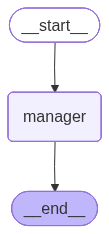

In [4]:
# Setup SQLite persistence
conn = sqlite3.connect("tasks_memory01.db", check_same_thread=False)
memory = SqliteSaver(conn)

# Compile graph
graph = builder.compile(checkpointer=memory)
graph

In [30]:
# -------- SESSION INPUT --------
config = {"configurable": {"thread_id": "user_1"}}

# Session input
input_data = {"tasks": ["Buy Bread"]}

result = graph.invoke(input_data, config)

print(result)

{'tasks': ['Buy Bread']}


In [5]:
# -------- SESSION INPUT --------
config = {"configurable": {"thread_id": "user_1"}}

# Session input
input_data = {"tasks": ["Buy Pen"]}

result = graph.invoke(input_data, config)

print(result)

{'tasks': ['Buy Bread', 'Buy Milk', 'Buy Pen']}


In [9]:
from rich import print
# Get the state history based on the config
state_history = graph.get_state_history(config)

# Print or inspect the state history
print(state_history)


#  iterate through the states
for i, state in enumerate(state_history):
    print(f"State {i + 1}: {state}")

<generator object Pregel.get_state_history at 0x0000021426434460>

State 1: StateSnapshot(values={'tasks': ['Buy Bread', 'Buy Milk', 'Buy Pen']}, next=(), config={'configurable': 
{'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66c-87b1-6c2b-8007-3e195927c70a'}}, 
metadata={'source': 'loop', 'step': 7, 'parents': {}}, created_at='2026-03-11T16:24:31.257659+00:00', 
parent_config={'configurable': {'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d66c-87a6-6ef6-8006-c1fe1ab073d5'}}, tasks=(), interrupts=())

State 2: StateSnapshot(values={'tasks': ['Buy Bread', 'Buy Milk', 'Buy Pen']}, next=('manager',), 
config={'configurable': {'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d66c-87a6-6ef6-8006-c1fe1ab073d5'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, 
created_at='2026-03-11T16:24:31.253237+00:00', parent_config={'configurable': {'thread_id': 'user_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d66c-879b-6695-8005-9feb6c26ceff'}}, 
tasks=(PregelTask(id='db06ae8c-89ec-d926-3d6f-8ebef71927f8', name='manager', path=('__pregel_pull', 'manager'), 
error=None, interrupts=(), state=None, result={'tasks': []}),), interrupts=())

State 3: StateSnapshot(values={'tasks': ['Buy Bread', 'Buy Milk']}, next=('__start__',), config={'configurable': 
{'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66c-879b-6695-8005-9feb6c26ceff'}}, 
metadata={'source': 'input', 'step': 5, 'parents': {}}, created_at='2026-03-11T16:24:31.248503+00:00', 
parent_config={'configurable': {'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d66a-ee9a-6556-8004-ac72ff3496ed'}}, tasks=(PregelTask(id='50a35265-e103-98f5-3bd3-0e7c06971877', 
name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'tasks': 
['Buy Pen']}),), interrupts=())

State 4: StateSnapshot(values={'tasks': ['Buy Bread', 'Buy Milk']}, next=(), config={'configurable': {'thread_id': 
'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-ee9a-6556-8004-ac72ff3496ed'}}, metadata={'source': 
'loop', 'step': 4, 'parents': {}}, created_at='2026-03-11T16:23:48.361318+00:00', parent_config={'configurable': 
{'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-ee93-60cd-8003-e47e15f12e6e'}}, tasks=(), 
interrupts=())

State 5: StateSnapshot(values={'tasks': ['Buy Bread', 'Buy Milk']}, next=('manager',), config={'configurable': 
{'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-ee93-60cd-8003-e47e15f12e6e'}}, 
metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-11T16:23:48.358330+00:00', 
parent_config={'configurable': {'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': 
'1f11d66a-ee77-6167-8002-7d368c2df086'}}, tasks=(PregelTask(id='1c25b1af-45a7-a4f1-b94b-ec5d7b99f498', 
name='manager', path=('__pregel_pull', 'manager'), error=None, interrupts=(), state=None, result={'tasks': []}),), 
interrupts=())

State 6: StateSnapshot(values={'tasks': ['Buy Bread']}, next=('__start__',), config={'configurable': {'thread_id': 
'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-ee77-6167-8002-7d368c2df086'}}, metadata={'source': 
'input', 'step': 2, 'parents': {}}, created_at='2026-03-11T16:23:48.346868+00:00', parent_config={'configurable': 
{'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-0a1d-6778-8001-d89cdedd36b1'}}, 
tasks=(PregelTask(id='80efb416-6003-4274-9b98-1a5cce05af9e', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'tasks': ['Buy Milk']}),), interrupts=())

State 7: StateSnapshot(values={'tasks': ['Buy Bread']}, next=(), config={'configurable': {'thread_id': 'user_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-0a1d-6778-8001-d89cdedd36b1'}}, metadata={'source': 'loop', 'step':
1, 'parents': {}}, created_at='2026-03-11T16:23:24.402639+00:00', parent_config={'configurable': {'thread_id': 
'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-0a12-6756-8000-3c259002ef48'}}, tasks=(), interrupts=())

State 8: StateSnapshot(values={'tasks': ['Buy Bread']}, next=('manager',), config={'configurable': {'thread_id': 
'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-0a12-6756-8000-3c259002ef48'}}, metadata={'source': 
'loop', 'step': 0, 'parents': {}}, created_at='2026-03-11T16:23:24.398127+00:00', parent_config={'configurable': 
{'thread_id': 'user_1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-0a07-6ddb-bfff-6dbf86938f7e'}}, 
tasks=(PregelTask(id='55cf0f2c-b059-a9d1-8a1d-30d5f20be689', name='manager', path=('__pregel_pull', 'manager'), 
error=None, interrupts=(), state=None, result={'tasks': []}),), interrupts=())

State 9: StateSnapshot(values={'tasks': []}, next=('__start__',), config={'configurable': {'thread_id': 'user_1', 
'checkpoint_ns': '', 'checkpoint_id': '1f11d66a-0a07-6ddb-bfff-6dbf86938f7e'}}, metadata={'source': 'input', 
'step': -1, 'parents': {}}, created_at='2026-03-11T16:23:24.393788+00:00', parent_config=None, 
tasks=(PregelTask(id='0af9eae5-d9c3-0d82-b2c0-3f6555f47d65', name='__start__', path=('__pregel_pull', '__start__'),
error=None, interrupts=(), state=None, result={'tasks': ['Buy Bread']}),), interrupts=())